# Feature Engineering, Model Optimization & Performance Comparison

## AIML Internship – Task 2

**Name:** Rumy Hota

**Organization:** Maincrafts Technologies

### Objective
To improve the performance of a machine learning model using feature engineering, feature scaling, model optimization, and performance comparison.

## Step 1: Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score


Step 2: Load the Dataset

In [ ]:
data = fetch_california_housing(as_frame=True)
df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Step 3: Separate Features and Target Variable

In [ ]:
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

Step 4: Feature Scaling

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Step 5: Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y , test_size = 0.2, random_state=42
)

Step 6: Train Multiple Models

In [10]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha =1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth = 5),
}

Step 7: Model Evaluation & Performance Comparison

In [12]:
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results[model_name] = {
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    }

# Display Results
results_df = pd.DataFrame(results).T
results_df = results_df.round(3)

print(results_df)

                     MSE   RMSE  R2 Score
Linear Regression  0.556  0.746     0.576
Ridge Regression   0.556  0.746     0.576
Decision Tree      0.525  0.724     0.600


Step 8: Visualize Performance and Validation

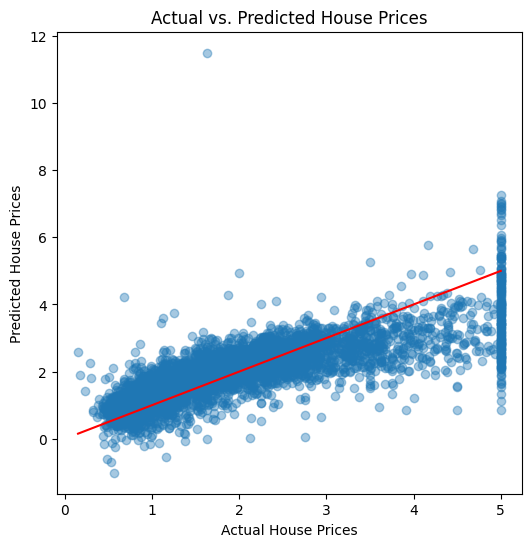

In [13]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred , alpha = 0.4)
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs. Predicted House Prices")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
      color = 'red'   )
plt.show()

 Conclusion





In this task, multiple machine learning regression models were trained and evaluated using the California Housing dataset. The dataset was preprocessed by separating the features and target variable, splitting it into training and testing sets, and applying feature scaling where required.

The performance of Linear Regression, Ridge Regression, and Decision Tree Regressor was compared using evaluation metrics such as RMSE and R² Score. The comparison showed that different models produced different levels of prediction accuracy. The model with the highest R² Score and the lowest RMSE was considered the best-performing model.

This task provided practical experience in feature scaling, model training, performance evaluation, and model comparison using Scikit-learn. It also enhanced the understanding of selecting the most suitable machine learning model based on evaluation metrics.